In [2]:
# Init the environment
import sys
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
sys.path.insert(0, "../..")

from init_physics_env import *

def nsolve_ineq(equation, expected_val, greater, var, start, step, max_iters=1000):
    curr = start
    for _ in range(max_iters):
        val = equation.subs(var, curr).evalf()
        if (greater and val >= expected_val) or (not greater and val <= expected_val):
            return curr
        curr += step
    raise RuntimeError("Couldn't find solution in given iteration count!")

## IQB-Aufgabe 2025_M_erhoeht_B_Analysis_MMS_2

### 1.
$$
\begin{align*}
f_b(x) &:= \frac1{16}x^2 e^{-bx+4b}~,\,b\in\mathbb R^+
\end{align*}
$$

In [3]:
b, x = symbols("b x", real=True)

f = Rational(1,16)*x**2*E**(-b*x+4*b)

#### a.
$$
\begin{align*}
\lim_{x\to\infty}f_b(x) &= 0 \\
\lim_{x\to-\infty}f_b(x) &= \infty
\end{align*}
$$

$$
\begin{align*}
f_b(4) &= \frac1{16}\cdot4^2\cdot e^{-b\cdot4 + 4b} \\
&= e^{0} \\
&= 1 \\
\Rightarrow f_b(4) &= 1~\,\forall b\in\mathbb R^+&
\end{align*}
$$

#### b.
$$
\begin{align*}
f'_b(x) &= 0
\end{align*}
$$

In [5]:
sols_diff = solve(f.diff(x), x)
sols_diff

$$
\begin{align*}
\rightarrow x_1 = 0&\,,~x_2 = \frac2b \\
\end{align*}
$$

In [11]:
(
    Eq(Symbol("f''_{b}(x_1)"), f.diff(x,x).subs(x, 0)),
    Eq(Symbol("f''_{b}(x_2)"), f.diff(x,x).subs(x, 2/b).simplify())
)

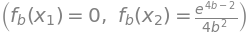

In [12]:
(
    Eq(Symbol("f_{b}(x_1)"), f.subs(x, 0)),
    Eq(Symbol("f_{b}(x_2)"), f.subs(x, 2/b).simplify())
)

$$
\begin{align*}
\rightarrow T\left(0\middle|0\right) \\
\rightarrow H\left(\frac2b\middle|\frac{e^{4b-2}}{4b^2}\right) \\
\end{align*}
$$

$$
\begin{align*}
d(b) &= \sqrt{(x_T-x_H)^2 + (y_T-y_H)^2} \\
&= \sqrt{ \left( 0-\frac2b \right)^2 + \left( 0 - \frac{e^{4b-2}}{4b^2} \right)^2 } \\
d(b) &= 6
\end{align*}
$$

In [23]:
dist_b_eq = (-2/b)**2 + (E**(4*b-2)/(4*b**2))**2 - 36
sol_dist_b = [nsolve(dist_b_eq, b, -0.2), nsolve(dist_b_eq, b, 0.1), nsolve(dist_b_eq, b, 1)]
sol_dist_b

$$
\begin{align*}
\Rightarrow b \approx 0,34
\end{align*}
$$

#### c.
Die Aussage ist wahr, solange jeder Funktionswert von $f_b$ für $x\in\mathbb R^+$ größer als $0$ ist:
$$
\begin{align*}
f_b(x) &>0 \\
\frac1{16}\cdot x^2\cdot e^{-bx + 4b} &> 0 \\
x^2\cdot e^{-bx + 4b} &> 0 \\
x^2 &> 0~,\,x\neq0 \\
e^{-bx + 4b} &> 0 \\
\Rightarrow x^2\cdot e^{-bx + 4b} &> 0 ~~\text{w.A.}
\end{align*}
$$

### 2.
$$
\begin{align*}
r(x) &:= \frac1{16}x^2 e^{-0,25x+1} \\
D_r &:= [-4;10] \subset \mathbb R
\end{align*}
$$

In [25]:
r = f.subs(b, Rational(1,4))

#### a.
Die Höhe des Startpodests $h_S$ und des Endpunkts $h_E$ der Rutschbahn entsprechen jeweils dem Wert von $r(x)$ an der unteren und oberen Grenze seines Definitionsbereiches:

$$
\begin{align*}
h_S &= r(-4) \\
h_E &= r(10)
\end{align*}
$$

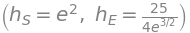

In [27]:
(
    Eq(Symbol("h_S"), r.subs(x,-4).simplify()),
    Eq(Symbol("h_E"), r.subs(x,10).simplify()),
)

#### b.
Der Winkel $\beta$ entspricht im Sachzusammenhang dem kleineren Winkel zwischen dem Startpodest und dem Anfang der Rutschbahn.

#### c.
$$
\begin{align*}
b &:= 1,5 \\
h &:= 0,05 \\
\end{align*}
$$

$$
\begin{align*}
r(x_d) &= h \\
&= 0,05
\end{align*}
$$

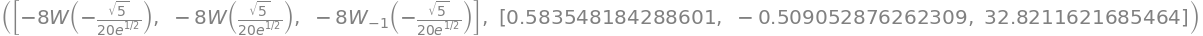

In [30]:
sols_r_height = solve(r-Rational(5,100))
(
    sols_r_height,
    [s.evalf() for s in sols_r_height]
)

$$
\begin{align*}
\rightarrow x_{d1,d2} &= -8\text W\left(\pm \frac{\sqrt5}{20\sqrt e} \right)
\end{align*}
$$

$$
\begin{align*}
V &= b \cdot \left| \int_{x_{d1}}^{x_{d2}}(r(x)-h)dx \right|
\end{align*}
$$

In [31]:
Eq(Symbol("V"), (Rational(-3,2)*Integral(r-Rational(5,100), [x, sols_r_height[1].evalf(100), sols_r_height[0].evalf(100)])).evalf())

Das Volumen des Wassers in der Mulde entspricht ca. $0,054 \text{ m}^3$ bzw. $54 \text{ l}$.

## IQB-Aufgabe 2024_M_erhoeht_B_Analysis_MMS_2

### 1.
$$
\begin{align*}
f_a(x) &= a^{-3}x^3 - a^{-1}x^2 + x ~,\,a\in\mathbb R^+
\end{align*}
$$

In [40]:
a = Symbol("a")
f = a**-3*x**3 - a**-1*x**2 + x

#### a.
$$
\begin{align*}
f'_4(x) &= -\frac14
\end{align*}
$$

In [41]:
solve(f.diff(x).subs(a, 4)+Rational(1,4))

$$
\begin{align*}
x_1 &= 4 \\
x_2 &= \frac{20}3
\end{align*}
$$

#### b.
$$
\begin{align*}
f(2) &= 2 \\
a^{-3}2^3 - a^{-1}2^2 + 2 &= 2 \\
\end{align*}
$$

In [42]:
solve(f.subs(x, 2)-2)

$$
\begin{align*}
\rightarrow a &= \sqrt2
\end{align*}
$$

#### c.
$$
\begin{align*}
f_1(x) &= f_2(x)
\end{align*}
$$

In [46]:
sols_c = solve(f.subs(a, 1)-f.subs(a, 2))
sols_c

$$
\begin{align*}
x_1 &= 0 \\
x_2 &= \frac47 \\
P_1&(x_1|f_1(x_1)) \\
P_2&(x_2|f_1(x_2)) \\
\end{align*}
$$

In [49]:
(
    Eq(Symbol("f_{1}(x_{1})"), f.subs(a, 1).subs(x, sols_c[0])),
    Eq(Symbol("f_{1}(x_{2})"), f.subs(a, 1).subs(x, sols_c[1])),
)

$$
\begin{align*}
P_1&\left( 0 \middle| 0 \right) \\
P_1&\left( \frac47 \middle| \frac{148}{343} \right) \\
\end{align*}
$$

$$
\begin{align*}
f_a(x) &= f_b(x) ~,\,a,b\in\mathbb R^+ \\
a^{-3}x^3 - a^{-1}x^2 + x &= b^{-3}x^3 - b^{-1}x^2 + x \\
x\left(a^{-3}x^2 - a^{-1}x + 1\right) &= x\left(b^{-3}x^2 - b^{-1}x + 1\right) \\
\rightarrow x=0 &\in\mathcal L
\end{align*}
$$

Wie zu erkennen ist, haben zwei Graphen von beliebigen Funktionen der Funktionenschar bei $x=0$ einen gemeinsamen Punkt.

#### d.
$$
\begin{align*}
n &- \text{Anzahl Nullstellen von }f_a \\
n &= \begin{cases}
3 & a^3(a-4) \geq 0 \\
1 & a^3(a-4) < 0
\end{cases}
\end{align*}
$$

Damit es drei Nullstellen gibt, müssen alle gegebenen Terme definiert sein. Der Term $0$ ist immer definiert, die Terme $\displaystyle \frac{a^2+\sqrt{a^3(a-4)}}{2} $ und $\displaystyle \frac{a^2-\sqrt{a^3(a-4)}}{2} $ sind allerdings nur dann in den reellen Zahlen definiert, wenn $a^3(a-4)$ größer oder gleich null ist, da sonst die Wurzel einer negativen Zahl gezogen werden würde, was unter den reellen Zahlen nicht definiert ist. Wenn $a^3(a-4)$ kleiner als null ist, sind die zwei letzteren Nullstellen also nicht definiert. Da der Term $0$ aber immer definiert ist, die Anzahl der Nullstellen für $a^3(a-4)<0$ also immer noch $1$.

#### e.
$$
\begin{align*}
f_a''(x) &= 0
\end{align*}
$$

In [51]:
sol_curve = solve(f.diff(x,x), x)
sol_curve

$$
\begin{align*}
\rightarrow W&\left(\frac{a^2}e\middle|f_a\left(\frac{a^2}3\right)\right) \\
\rightarrow y_W(a) &= f_a\left(\frac{a^2}3\right) \\
y_W'(a) = 0 &\land y_W''(a) < 0
\end{align*}
$$

In [57]:
yw = f.subs(x, sol_curve[0])
sol_ymax = list(filter(lambda x : yw.diff(a,a).subs(a,x).evalf() < 0, solve(yw.diff(a))))
sol_ymax

$$
\begin{align*}
\Rightarrow a &= 3
\end{align*}
$$

#### f.
* Schritt eins: Funktion und $y$ von Gerade $g$ wurden gleich gesetzt und nach $x$ umgestellt
* Schritt zwei: Flächeninhalt von Dreieck mit Grundseitenlänge $a^2$ und Höhenlänge $f_a(a^2)$ (oder umgekehrt) wird gleich dem Dreifachen des Flächeninhalts zwischen der Gerade $g$ und dem Graphen der Funktion $f_a$ im Intervall $[0;a^2]$ gesetzt und es wurde nach $x$ umgestellt

Für $a=2$ ist der Inhalte der Fläche, die von der Gerade $g$ und dem Graphen von $f_a$ eingeschlossen wird, so groß wie ein Drittel der Fläche des rechtwinkligen Dreiecks mit den Punkten $O$, $P$ und $Q(u_a|0)$.